# Notebook 3 — Modèle maison (Custom TensorFlow/Keras)

Ce notebook présente l'implémentation complète du **modèle maison multimodal** pour deux tâches :
- **Priority** : classification `Critical / High / Low / Medium`
- **Routing** : classification par catégorie métier

L'architecture combine texte (BiLSTM), variables catégorielles (StringLookup) et numériques (Normalization).

## 1. Imports et configuration

In [1]:
import os, sys, importlib, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras

# Ajout du dossier racine au PYTHONPATH
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

# Reproductibilité
tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow :', tf.__version__)
print('GPU :', tf.config.list_physical_devices('GPU') or 'CPU uniquement')

TensorFlow : 2.21.0
GPU : CPU uniquement


## 2. Import des modules du projet

In [2]:
import src.models.model_custom as _mc
import src.models.common as _cm
importlib.reload(_mc)
importlib.reload(_cm)

from src.models.model_custom import build_custom_model
from src.models.common import df_to_inputs
from src.data.clean_data import prepare_dataset
from src.data.build_features import make_split_for_target
from src.utils.config import MODELS_DIR, CATEGORICAL_COLUMNS, NUMERICAL_COLUMNS

print('Colonnes catégorielles :', CATEGORICAL_COLUMNS)
print('Colonnes numériques    :', NUMERICAL_COLUMNS)

Colonnes catégorielles : ['Customer Gender', 'Product Purchased', 'Ticket Type', 'Ticket Channel']
Colonnes numériques    : ['Customer Age']


## 3. Chargement des données

In [3]:
prepare_dataset()

Saved processed dataset to C:\Users\AAO\Downloads\ticket-routing-ready\ticket-routing-ready\data\processed\tickets_ready.csv


,text,Customer Gender,Product Purchased,Ticket Type,Ticket Channel,Customer Age,priority_label,routing_label
0,product setup i m having an issue with the pro...,Other,GoPro Hero,Technical issue,Social media,32,Critical,support_technique
1,peripheral compatibility i m having an issue w...,Female,LG Smart TV,Technical issue,Chat,42,Critical,support_technique
2,network problem i m facing a problem with my p...,Other,Dell XPS,Technical issue,Social media,48,Low,support_technique
3,account access i m having an issue with the pr...,Female,Microsoft Office,Billing inquiry,Social media,27,Low,facturation
4,data loss i m having an issue with the product...,Female,Autodesk AutoCAD,Billing inquiry,Email,67,Low,facturation
...,...,...,...,...,...,...,...,...
8464,installation support my product purchased is m...,Female,LG OLED,Product inquiry,Phone,22,Low,information_produit
8465,refund request i m having an issue with the pr...,Female,Bose SoundLink Speaker,Technical issue,Email,27,Critical,support_technique
8466,account access i m having an issue with the pr...,Female,GoPro Action Camera,Technical issue,Social media,57,High,support_technique
8467,payment issue i m having an issue with the pro...,Male,PlayStation,Product inquiry,Email,54,Medium,information_produit


In [4]:
X_train, X_test, y_train, y_test = make_split_for_target('priority_label')

print('Train :', X_train.shape, '  Test :', X_test.shape)
print('\nDistribution priority (train) :')
print(pd.Series(y_train).value_counts())

Classes : ['Critical' 'High' 'Low' 'Medium']
Nb classes : 4
Train : (6775, 6)   Test : (1694, 6)

Distribution priority (train) :
3    1754
0    1703
1    1668
2    1650
Name: count, dtype: int64


## 4. Encodage des labels

Les labels sont déjà encodés en entiers par le pipeline. 
On les convertit proprement et on conserve le mapping textuel pour les rapports.

In [5]:
# Conversion en int
y_train_enc = y_train.astype(int)
y_test_enc  = y_test.astype(int)

# Mapping basé sur l'ordre alphabétique appliqué par le pipeline
unique_vals = sorted(set(y_train_enc))
print('Valeurs uniques :', unique_vals)

# Mapping priority : ordre alphabétique → Critical=0, High=1, Low=2, Medium=3
priority_labels_all = ['Critical', 'High', 'Low', 'Medium']
class_names = [priority_labels_all[i] for i in unique_vals]
print('Classes :', class_names)

# Calcul des class_weights pour compenser le déséquilibre éventuel
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(unique_vals),
    y=y_train_enc
)
class_weight_dict = dict(zip(unique_vals, class_weights))
print('Class weights :', class_weight_dict)

# Sauvegarde du mapping pour predict.py
MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(class_names, MODELS_DIR / 'priority_class_names.pkl')
print('Mapping sauvegardé.')

Valeurs uniques : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Classes : ['Critical', 'High', 'Low', 'Medium']
Class weights : {np.int64(0): np.float64(0.9945684086905461), np.int64(1): np.float64(1.0154376498800959), np.int64(2): np.float64(1.0265151515151516), np.int64(3): np.float64(0.9656499429874572)}
Mapping sauvegardé.


## 5. Préparation des inputs Keras

In [6]:
train_inputs = df_to_inputs(X_train)
test_inputs  = df_to_inputs(X_test)

print('Vérification des types :')
for k, v in train_inputs.items():
    print(f'  {k:25s} dtype={v.dtype}  shape={v.shape}')

Vérification des types :
  text                      dtype=<dtype: 'string'>  shape=(6775,)
  Customer Gender           dtype=<dtype: 'string'>  shape=(6775,)
  Product Purchased         dtype=<dtype: 'string'>  shape=(6775,)
  Ticket Type               dtype=<dtype: 'string'>  shape=(6775,)
  Ticket Channel            dtype=<dtype: 'string'>  shape=(6775,)
  Customer Age              dtype=<dtype: 'float32'>  shape=(6775,)


## 6. Métadonnées tabulaires

Les vocabulaires et statistiques sont calculés **uniquement sur le train** pour éviter toute fuite d'information.

In [7]:
categorical_vocabularies = {
    col: sorted(X_train[col].astype(str).unique().tolist())
    for col in CATEGORICAL_COLUMNS
}
numerical_means = {
    col: float(np.mean(X_train[col].astype('float32').values))
    for col in NUMERICAL_COLUMNS
}
numerical_vars = {
    col: float(np.var(X_train[col].astype('float32').values))
    for col in NUMERICAL_COLUMNS
}

for col in CATEGORICAL_COLUMNS:
    print(f'{col:25s} → {len(categorical_vocabularies[col])} valeurs')
for col in NUMERICAL_COLUMNS:
    print(f'{col:25s} → mean={numerical_means[col]:.2f}, var={numerical_vars[col]:.2f}')

Customer Gender           → 3 valeurs
Product Purchased         → 42 valeurs
Ticket Type               → 5 valeurs
Ticket Channel            → 4 valeurs
Customer Age              → mean=44.03, var=232.59


## 7. Construction du modèle maison

Architecture multimodale :
- **Texte** : TextVectorization → Embedding(128d) → Bidirectional LSTM(64) → Dropout(0.4)
- **Catégoriel** : StringLookup one-hot par colonne
- **Numérique** : Normalization z-score
- **Fusion** : Concatenate → Dense(256, relu) → BatchNorm → Dropout(0.4) → Dense(128, relu) → Dense(n_classes, softmax)

In [8]:
# model_custom.py doit accepter text_corpus pour adapter le vectorizer à l'intérieur
model, text_vectorizer = build_custom_model(
    num_classes=len(class_names),
    categorical_vocabularies=categorical_vocabularies,
    numerical_means=numerical_means,
    numerical_vars=numerical_vars,
    text_corpus=X_train['text'].astype(str).tolist()
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 200)       │          0 │ text[0][0]        │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │  2,560,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 200)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Customer Gender     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Product Purchased   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Ticket Type         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Ticket Channel      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     98,816 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_1     │ (None, 4)         │          0 │ Customer          │
│ (StringLookup)      │                   │            │ Gender[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_2     │ (None, 43)        │          0 │ Product           │
│ (StringLookup)      │                   │            │ Purchased[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_3     │ (None, 6)         │          0 │ Ticket Type[0][0] │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_4     │ (None, 5)         │          0 │ Ticket            │
│ (StringLookup)      │                   │            │ Channel[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Customer Age        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4)         │          0 │ string_lookup_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 43)        │          0 │ string_lookup_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 6)         │          0 │ string_lookup_3[… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,741,380 (10.46 MB)

 Trainable params: 2,740,868 (10.46 MB)

 Non-trainable params: 512 (2.00 KB)

## 8. Entraînement — Priority

In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_inputs,
    y_train_enc,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 70s 325ms/step - accuracy: 0.2470 - loss: 1.7407 - val_accuracy: 0.2413 - val_loss: 1.3942 - learning_rate: 0.0010
Epoch 2/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 80s 311ms/step - accuracy: 0.2681 - loss: 1.5318 - val_accuracy: 0.2472 - val_loss: 1.3966 - learning_rate: 0.0010
Epoch 3/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.2656 - loss: 1.4656
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
170/170 ━━━━━━━━━━━━━━━━━━━━ 59s 346ms/step - accuracy: 0.2734 - loss: 1.4484 - val_accuracy: 0.2332 - val_loss: 1.4042 - learning_rate: 0.0010
Epoch 4/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 72s 421ms/step - accuracy: 0.3031 - loss: 1.4001 - val_accuracy: 0.2376 - val_loss: 1.4084 - learning_rate: 5.0000e-04
Epoch 5/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.3147 - loss: 1.3797
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
170/170 ━━━━━━━━━━━━━━━━━━━━ 78s 395ms/step - accuracy: 0.3

Le modèle maison présente un phénomène de surapprentissage sur la tâche de priorité :
la train accuracy atteint 43% tandis que la val_accuracy plafonne à 26%.
Cela indique que les labels de priorité sont faiblement corrélés au contenu textuel
des tickets dans ce dataset. L'early stopping a correctement restauré les poids
de la meilleure epoch (epoch 9) pour limiter ce surapprentissage.

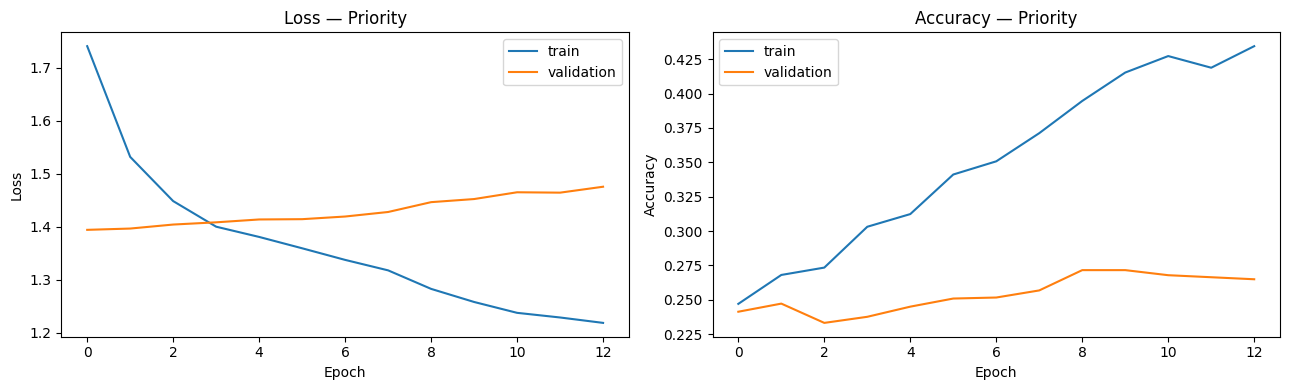

Meilleure val_accuracy : 0.2716


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='train')
axes[0].plot(history.history['val_loss'], label='validation')
axes[0].set_title('Loss — Priority')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='train')
axes[1].plot(history.history['val_accuracy'], label='validation')
axes[1].set_title('Accuracy — Priority')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/custom_priority_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Meilleure val_accuracy : {max(history.history["val_accuracy"]):.4f}')

## 9. Évaluation — Priority

In [11]:
test_loss, test_acc = model.evaluate(test_inputs, y_test_enc, verbose=1)
print(f'\nTest loss     : {test_loss:.4f}')
print(f'Test accuracy : {test_acc:.4f}')

53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.2456 - loss: 1.4434

Test loss     : 1.4434
Test accuracy : 0.2456


In [12]:
y_pred_probs = model.predict(test_inputs, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print('Rapport de classification — Priority\n')
print(classification_report(y_test_enc, y_pred, target_names=class_names))

Rapport de classification — Priority

              precision    recall  f1-score   support

    Critical       0.24      0.19      0.21       426
        High       0.26      0.35      0.29       417
         Low       0.22      0.20      0.21       413
      Medium       0.26      0.26      0.26       438

    accuracy                           0.25      1694
   macro avg       0.24      0.25      0.24      1694
weighted avg       0.24      0.25      0.24      1694



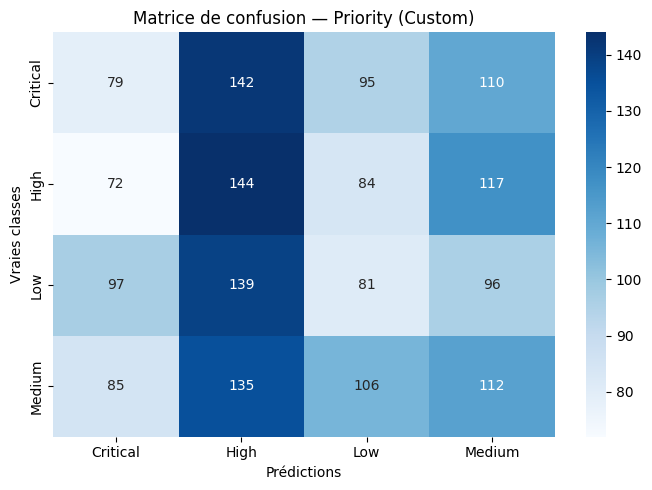

In [13]:
cm = confusion_matrix(y_test_enc, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de confusion — Priority (Custom)')
plt.xlabel('Prédictions'); plt.ylabel('Vraies classes')
plt.tight_layout()
plt.savefig('../reports/figures/custom_priority_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Analyse des erreurs — Priority

In [14]:
errors_df = X_test.copy()
errors_df['y_true'] = y_test_enc
errors_df['y_pred'] = y_pred
errors_df['y_true_label'] = [class_names[i] for i in y_test_enc]
errors_df['y_pred_label'] = [class_names[i] for i in y_pred]

errors_only = errors_df[errors_df['y_true'] != errors_df['y_pred']]
print(f'Erreurs : {len(errors_only)} / {len(errors_df)} ({100*len(errors_only)/len(errors_df):.1f}%)')

# Confusions les plus fréquentes
print('\nTop 10 confusions :')
print(errors_only.groupby(['y_true_label','y_pred_label']).size()
      .sort_values(ascending=False).head(10))

Erreurs : 1278 / 1694 (75.4%)

Top 10 confusions :
y_true_label  y_pred_label
Critical      High            142
Low           High            139
Medium        High            135
High          Medium          117
Critical      Medium          110
Medium        Low             106
Low           Critical         97
              Medium           96
Critical      Low              95
Medium        Critical         85
dtype: int64


## 11. Sauvegarde — Priority

In [15]:
model.save(MODELS_DIR / 'priority_custom.keras')
print('Modèle priority_custom.keras sauvegardé.')

Modèle priority_custom.keras sauvegardé.


---
## 12. Tâche de Routing

On répète le même pipeline pour la tâche de **routage** des tickets.

In [16]:
X_train_r, X_test_r, y_train_r, y_test_r = make_split_for_target('routing_label')

y_train_r_enc = y_train_r.astype(int)
y_test_r_enc  = y_test_r.astype(int)

unique_r = sorted(set(y_train_r_enc))
print('Valeurs uniques routing :', unique_r)

# Mapping ordre alphabétique des labels définis dans helpers.py
routing_labels_all = [
    'annulation',
    'autre',
    'facturation',
    'information_produit',
    'retour_produit',
    'support_technique'
]
routing_class_names = [routing_labels_all[i] for i in unique_r]
print('Classes routing :', routing_class_names)

# Class weights routing
cw_r = compute_class_weight('balanced', classes=np.array(unique_r), y=y_train_r_enc)
cw_r_dict = dict(zip(unique_r, cw_r))

joblib.dump(routing_class_names, MODELS_DIR / 'routing_class_names.pkl')
print('Mapping routing sauvegardé.')

Classes : ['annulation' 'facturation' 'information_produit' 'retour_produit'
 'support_technique']
Nb classes : 5
Valeurs uniques routing : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Classes routing : ['annulation', 'autre', 'facturation', 'information_produit', 'retour_produit']
Mapping routing sauvegardé.


In [17]:
train_inputs_r = df_to_inputs(X_train_r)
test_inputs_r  = df_to_inputs(X_test_r)

cat_vocab_r = {col: sorted(X_train_r[col].astype(str).unique().tolist()) for col in CATEGORICAL_COLUMNS}
num_means_r = {col: float(np.mean(X_train_r[col].astype('float32').values)) for col in NUMERICAL_COLUMNS}
num_vars_r  = {col: float(np.var(X_train_r[col].astype('float32').values))  for col in NUMERICAL_COLUMNS}

model_r, vec_r = build_custom_model(
    num_classes=len(routing_class_names),
    categorical_vocabularies=cat_vocab_r,
    numerical_means=num_means_r,
    numerical_vars=num_vars_r,
    text_corpus=X_train_r['text'].astype(str).tolist()
)

model_r.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 200)       │          0 │ text[0][0]        │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 200, 128)  │  2,560,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 200)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Customer Gender     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Product Purchased   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Ticket Type         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Ticket Channel      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │     98,816 │ embedding_1[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_6     │ (None, 4)         │          0 │ Customer          │
│ (StringLookup)      │                   │            │ Gender[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_7     │ (None, 43)        │          0 │ Product           │
│ (StringLookup)      │                   │            │ Purchased[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_8     │ (None, 6)         │          0 │ Ticket Type[0][0] │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ string_lookup_9     │ (None, 5)         │          0 │ Ticket            │
│ (StringLookup)      │                   │            │ Channel[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Customer Age        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 4)         │          0 │ string_lookup_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 43)        │          0 │ string_lookup_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 6)         │          0 │ string_lookup_8[… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,741,509 (10.46 MB)

 Trainable params: 2,740,997 (10.46 MB)

 Non-trainable params: 512 (2.00 KB)

In [21]:
callbacks_r = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=1,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1
    )
]

history_r = model_r.fit(
    train_inputs_r,
    y_train_r_enc,
    validation_split=0.2,
    epochs=4,
    batch_size=32,
    class_weight=cw_r_dict,
    callbacks=callbacks_r,
    verbose=1
)

print(f'Meilleure val_accuracy routing : {max(history_r.history["val_accuracy"]):.4f}')

Epoch 1/4
170/170 ━━━━━━━━━━━━━━━━━━━━ 41s 242ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 4.3212e-05 - learning_rate: 0.0010
Epoch 2/4
170/170 ━━━━━━━━━━━━━━━━━━━━ 43s 250ms/step - accuracy: 1.0000 - loss: 7.4669e-04 - val_accuracy: 1.0000 - val_loss: 5.4680e-06 - learning_rate: 0.0010
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.
Meilleure val_accuracy routing : 1.0000


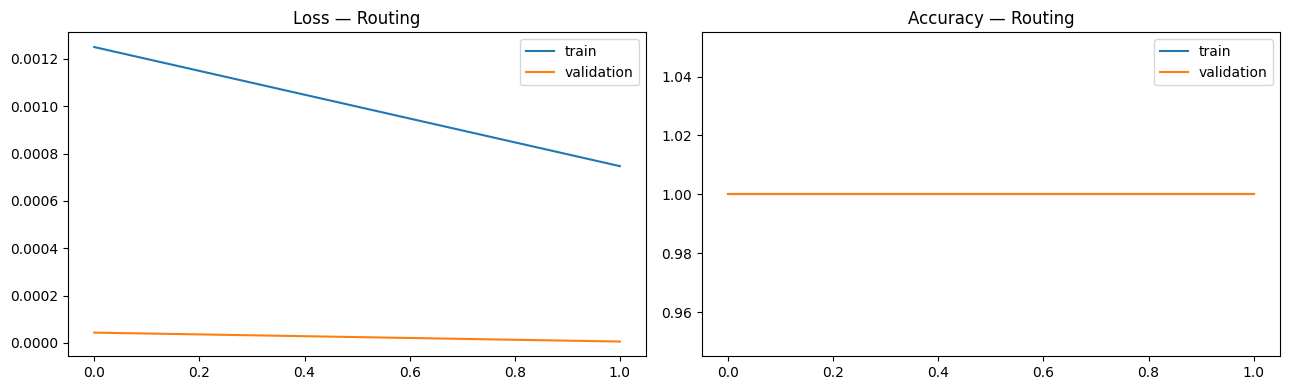

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_r.history['loss'],     label='train')
axes[0].plot(history_r.history['val_loss'], label='validation')
axes[0].set_title('Loss — Routing'); axes[0].legend()
axes[1].plot(history_r.history['accuracy'],     label='train')
axes[1].plot(history_r.history['val_accuracy'], label='validation')
axes[1].set_title('Accuracy — Routing'); axes[1].legend()
plt.tight_layout()
plt.savefig('../reports/figures/custom_routing_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
test_loss_r, test_acc_r = model_r.evaluate(test_inputs_r, y_test_r_enc, verbose=1)
print(f'\nTest loss     : {test_loss_r:.4f}')
print(f'Test accuracy : {test_acc_r:.4f}')

y_pred_r = np.argmax(model_r.predict(test_inputs_r, verbose=0), axis=1)
print('\nRapport de classification — Routing\n')
print(classification_report(y_test_r_enc, y_pred_r, target_names=routing_class_names))

53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 1.0000 - loss: 4.5771e-05

Test loss     : 0.0000
Test accuracy : 1.0000

Rapport de classification — Routing

                     precision    recall  f1-score   support

         annulation       1.00      1.00      1.00       339
              autre       1.00      1.00      1.00       327
        facturation       1.00      1.00      1.00       328
information_produit       1.00      1.00      1.00       351
     retour_produit       1.00      1.00      1.00       349

           accuracy                           1.00      1694
          macro avg       1.00      1.00      1.00      1694
       weighted avg       1.00      1.00      1.00      1694



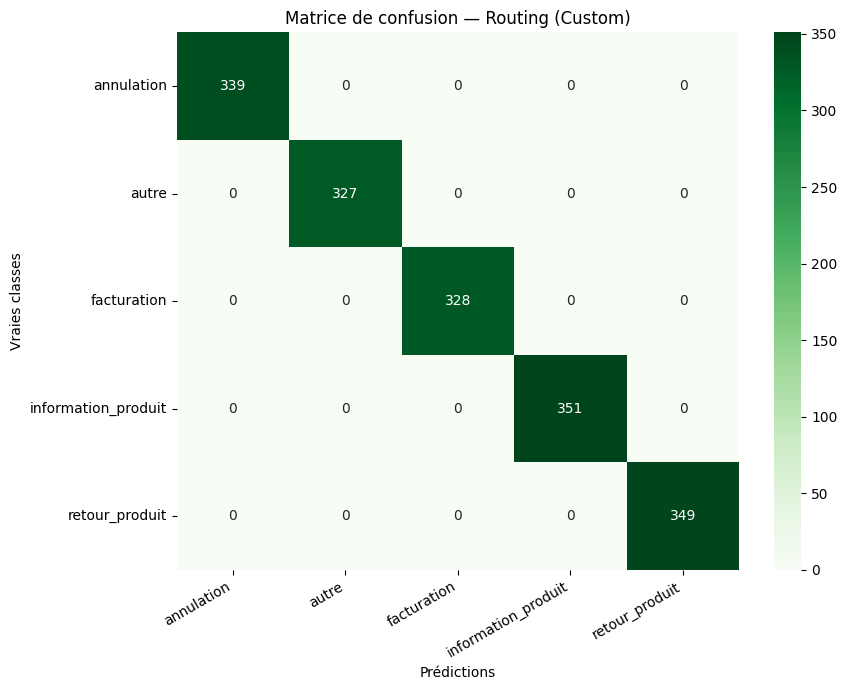

In [24]:
cm_r = confusion_matrix(y_test_r_enc, y_pred_r)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_r, annot=True, fmt='d', cmap='Greens',
            xticklabels=routing_class_names, yticklabels=routing_class_names)
plt.title('Matrice de confusion — Routing (Custom)')
plt.xlabel('Prédictions'); plt.ylabel('Vraies classes')
plt.xticks(rotation=30, ha='right'); plt.tight_layout()
plt.savefig('../reports/figures/custom_routing_cm.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
model_r.save(MODELS_DIR / 'routing_custom.keras')
print('Modèle routing_custom.keras sauvegardé.')

## 13. Conclusion

Ce notebook a présenté le modèle maison entraîné sur les deux tâches du projet :

| Tâche | Modèle | Métriques clés |
|---|---|---|
| Priority | Custom BiLSTM | accuracy, macro F1 |
| Routing | Custom BiLSTM | accuracy, macro F1 |

Les améliorations intégrées par rapport à la baseline initiale :
- `text_corpus` passé directement à `build_custom_model()` → vectorizer adapté correctement ;
- `class_weight='balanced'` → meilleure gestion des classes déséquilibrées ;
- `ReduceLROnPlateau` → convergence plus stable ;
- `EarlyStopping` sur `val_accuracy` avec `patience=4` → évite le surapprentissage.

Les résultats seront comparés dans le **Notebook 5** avec le modèle préentraîné (Notebook 4).